# ARTS ET METIERS - PGE2A - VIBRATIONS - ED3/4
## Modal Analysis - Coupled Mechanical System 

This notebook contains elements to study:
- ...

Contributed by E. Monteiro and E. Balmes  
Copyright (c) 2018-2026 by ENSAM, All Rights Reserved.

## Import useful libraries

In [1]:
import numpy as np
import scipy.linalg as linalg
import scipy.sparse as sparse

from mevib import cosd, sind, feeig, plot2D, plotFourier, plotFreq
from feplot import model, anim1D_mode


## Model for visualization

In [2]:
def build_model():
    mo1 = model()
    typ1 = [ord(s) for s in 'beam2']
    typ1.insert(0, np.inf)

    mo1.Node = np.array([
        [1,0.,0.,0.,1.,0.,0.],
        [2,0.,0.,0.,0.,1.,0.],
        [3,0.,0.,0.,1.,1.,0],
        [4,0.,0.,0.,2.,2.,0.],
        [5,0.,0.,0.,3.,2.,0.],
        [6,0.,0.,0.,2.,3.,0.]
    ])

    mo1.Elt = np.zeros((6,6))
    mo1.Elt[0,:] = typ1
    mo1.Elt = np.array([
        typ1,
        [1,3,0,0,0,0],
        [2,3,0,0,0,0],
        [3,4,0,0,0,0],
        [4,5,0,0,0,0],
        [4,6,0,0,0,0]
    ])

    mo1.DOF = np.array([3.01, 3.02, 4.01, 4.02])
    return mo1


## Part 1

#### Q1: matrices system

In [3]:
def q1(pa=[], pflag=True):
    if type(pa) == list:
        pa = dict([
            ('m',10.), ('L',1.), ('a',45.),
            ('k1',1000.0), ('k2',10000.), ('k3',1000.),
            ('Tend',10.), ('dt',0.1)
        ])

    c = cosd(pa['a'])
    s = sind(pa['a'])

    M = np.eye(4) * pa['m']

    K = np.array([
        [pa['k1']+pa['k3']*c**2,  pa['k3']*c*s,      -pa['k3']*c**2,   -pa['k3']*c*s],
        [pa['k3']*c*s,           pa['k1']+pa['k3']*s**2, -pa['k3']*c*s, -pa['k3']*s**2],
        [-pa['k3']*c**2,          -pa['k3']*c*s,     pa['k2']+pa['k3']*c**2, pa['k3']*c*s],
        [-pa['k3']*c*s,           -pa['k3']*s**2,    pa['k3']*c*s,     pa['k2']+pa['k3']*s**2]
    ])

    if pflag:
        print("M=\n", M, "\nK=\n", K)         
    else:
        return M, K


In [4]:
q1()

M=
 [[10.  0.  0.  0.]
 [ 0. 10.  0.  0.]
 [ 0.  0. 10.  0.]
 [ 0.  0.  0. 10.]] 
K=
 [[ 1500.   500.  -500.  -500.]
 [  500.  1500.  -500.  -500.]
 [ -500.  -500. 10500.   500.]
 [ -500.  -500.   500. 10500.]]


#### Q2: Modal Analysis

In [5]:
def q2(pa=[], idmode=1, pflag=True):
    if type(pa) == list:
        pa = dict([
            ('m',10.), ('L',1.), ('a',45.),
            ('k1',1000.0), ('k2',10000.), ('k3',1000.),
            ('Tend',10.), ('dt',0.1)
        ])

    M, K = q1(pa, pflag=False)
    om1, phi1 = feeig(K, M, norm='M')

    if pflag:
        print("omega =", om1)
        print("\nphi =\n", phi1)
        mo1 = build_model()
        fig1 = anim1D_mode(mo1, om1, phi1, idmode)
        return fig1
    else:
        return om1, phi1


omega = [10.         13.74855546 31.6227766  33.33132495]

phi =
 [[ 2.23606798e-01  2.22271628e-01  3.03665564e-18  2.43992519e-02]
 [-2.23606798e-01  2.22271628e-01 -3.72904607e-19  2.43992519e-02]
 [-2.15853134e-18  2.43992519e-02 -2.23606798e-01 -2.22271628e-01]
 [-2.15853134e-18  2.43992519e-02  2.23606798e-01 -2.22271628e-01]]


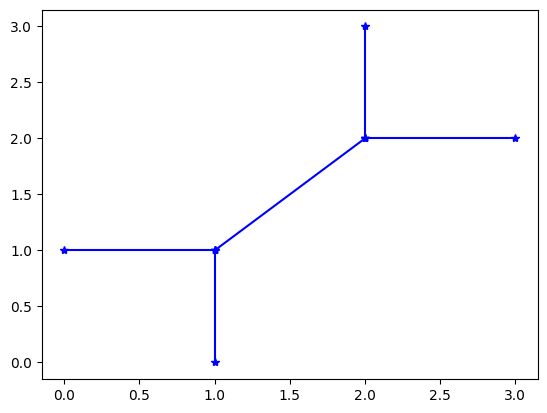

In [14]:
q2()

#### Q3: Coupling force

In [6]:
def q3():
    pa = dict([
        ('m',10.), ('L',1.), ('a',45.),
        ('k1',1000.0), ('k2',10000.), ('k3',1000.),
        ('Tend',10.), ('dt',0.1)
    ])

    om1, phi1 = q2(pa, pflag=False)

    c = cosd(pa['a'])
    s = sind(pa['a'])
    C = pa['k3'] * np.array([-c, -s, c, s])

    f3 = C @ phi1
    print("F3 =", f3)

    B = np.array([1,0,0,0])
    M, K = q1(pa, pflag=False)

    y1 = lambda s: C @ linalg.solve((1j*s)**2 * M + K, B)
    y2 = lambda s: (C @ phi1) @ np.diag(1 / ((1j*s)**2 + om1**2)) @ (phi1.T @ B)

    xyplot = {
        'X': np.linspace(0, 50, 1000),
        'Xlabel': 'w',
        'Ylabel': 'F3'
    }

    xyplot['Y'] = np.zeros((1000, 2))
    for j in range(1000):
        xyplot['Y'][j, :] = [y1(xyplot['X'][j]).real,
                              y2(xyplot['X'][j]).real]

    plotFreq(xyplot, gf=5)


F3 = [-1.13686838e-13 -2.79833797e+02 -2.84217094e-14 -3.48845304e+02]


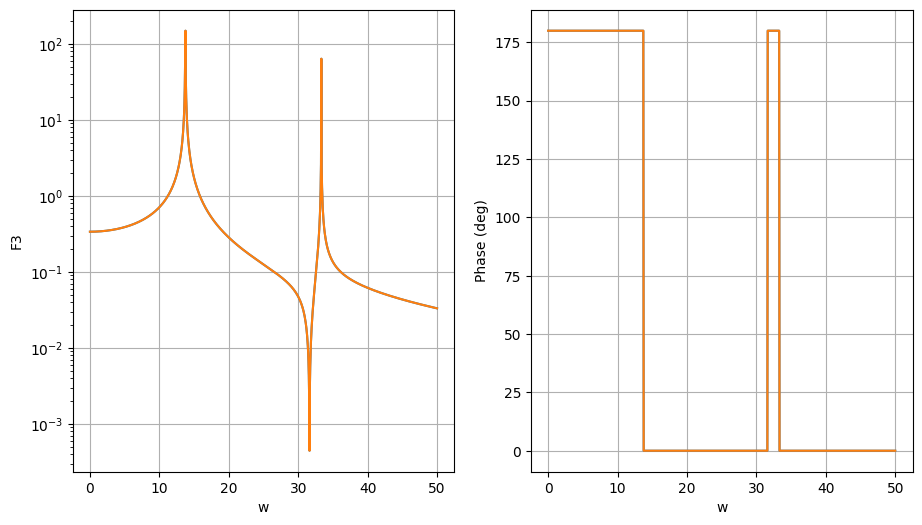

In [15]:
q3()

#### Q4: Damping

In [7]:
def q4():
    pa = dict([
        ('m',10.), ('L',1.), ('a',45.),
        ('k1',1000.0), ('k2',10000.), ('k3',1000.)
    ])

    om1, phi1 = q2(pa, pflag=False)
    M, K = q1(pa, pflag=False)

    bmax = 4. / om1[-1]
    X = np.linspace(0, bmax, int(np.ceil(bmax / 1e-4)))

    Y = np.zeros((len(X), len(om1)))
    for j in range(len(om1)):
        Y[:, j] = X * om1[j] / 2.

    plot2D({
        'X': X,
        'Y': Y,
        'Xlabel': 'Beta',
        'Ylabel': 'Damping ratio',
        'legend': np.arange(len(om1)) + 1
    }, gf=4)


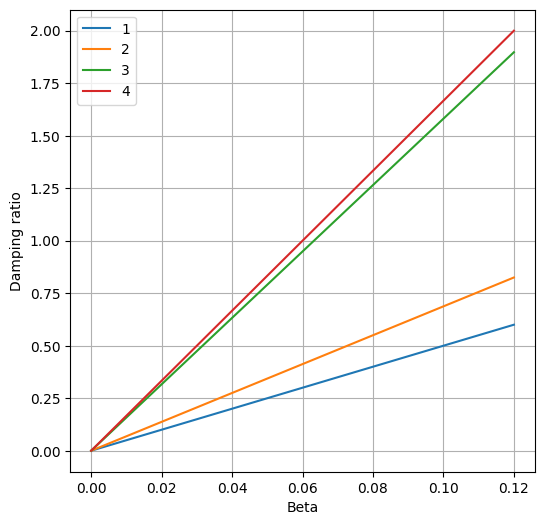

In [16]:
q4()

## Part 2

##### Q6: stiffness modification

In [8]:
def q6(cas=2, rate=0.05):
    pa = dict([
        ('m',10.), ('L',1.), ('a',45.),
        ('k1',1000.0), ('k2',10000.), ('k3',1000.)
    ])

    om1, phi1 = q2(pa, pflag=False)
    M, K = q1(pa, pflag=False)

    c = cosd(pa['a'])
    s = sind(pa['a'])
    z4 = [0.,0.,0.,0.]

    if cas == 1:
        idmode = 1
        dK = np.array([[c**2, c*s, 0, 0],
                       [c*s, s**2, 0, 0],
                       z4, z4])
    elif cas == 2:
        idmode = 1
        dK = np.array([[s**2, -c*s, 0, 0],
                       [-c*s, c**2, 0, 0],
                       z4, z4])

    ki = ((1+rate)**2 - 1) * om1[idmode-1]**2 / (phi1[:,idmode-1].T @ dK @ phi1[:,idmode-1])

    om2, phi2 = feeig(K + ki*dK, M)

    print("k =", ki)
    print("omega new =", om2)
    print("ratio =", om2 / om1)


In [17]:
q6()

k = 102.49999999986885
omega new = [10.5        13.74855546 31.6227766  33.33132495]
ratio = [1.05 1.   1.   1.  ]


#### Q7: Mass modification

In [9]:
def q7(m=-2.1):
    pa = dict([
        ('m',10.), ('L',1.), ('a',45.),
        ('k1',1000.0), ('k2',10000.), ('k3',1000.)
    ])

    om1, phi1 = q2(pa, pflag=False)
    M, K = q1(pa, pflag=False)

    dM = np.zeros((4,4))
    dM[0,0] = m

    om2, phi2 = feeig(K, M + dM)

    print("omega new =", om2)
    print("ratio =", om2 / om1)


In [18]:
q7()

omega new = [10.49273429 14.72981155 31.6227766  33.3587859 ]
ratio = [1.04927343 1.07137158 1.         1.00082388]


#### Test pyvista

In [19]:
import numpy as np
import pyvista as pv
pv.set_jupyter_backend('trame')
pv.global_theme.notebook = True

In [20]:
nodes=np.array([[0.,0.,0.], [1.,0.,0.],[0.,1.,0.],[1.,1.,0],[2.,2.,0.],[3.,2.,0.],[2.,3.,0]]) 
Elt=np.array([[1,3],[2,3],[3,4],[4,5],[4,6]],dtype=np.int8); Elt=np.hstack((np.ones((Elt.shape[0],1),dtype=np.int8)*int(2),Elt))

mesh = pv.PolyData(nodes, Elt)
print(mesh)

PolyData (0x1eedfabd360)
  N Cells:    5
  N Points:   7
  N Strips:   0
  X Bounds:   0.000e+00, 3.000e+00
  Y Bounds:   0.000e+00, 3.000e+00
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   0


In [23]:
pl = pv.Plotter()
pl.add_mesh(mesh,
    render_lines_as_tubes=True,
    style='wireframe',
    line_width=2,
    cmap='jet',
    show_scalar_bar=False,
)
pl.view_xy()
pl.show()

Widget(value='<iframe src="http://localhost:56169/index.html?ui=P_0x1eedf811040_2&reconnect=auto" class="pyvis…